# Treinamento Não Supervisionado

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [13]:
df = pd.read_csv("../data/silver/flights_delay_cancelled.csv", sep=",")
df

,DAY_OF_WEEK,AIRLANE_CODE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,ORIGIN_STATE_NAME,ORIGIN_COUNTRY_NAME,ORIGIN_LATITUDE_NAME,ORIGIN_LONGITUDE_NAME,DESTINATION_AIRPORT_NAME,DESTINATION_CITY_NAME,DESTINATION_STATE_NAME,DESTINATION_COUNTRY_NAME,DESTINATION_LATITUDE_NAME,DESTINATION_LONGITUDE_NAME
0,4,AS,98,N407AS,ANC,SEA,5,2354,-11.0,21.0,...,AK,USA,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931
1,4,AA,2336,N3KUAA,LAX,PBI,10,2,-8.0,12.0,...,CA,USA,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559
2,4,US,840,N171US,SFO,CLT,20,18,-2.0,16.0,...,CA,USA,37.61900,-122.37484,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
3,4,AA,258,N3HYAA,LAX,MIA,20,15,-5.0,15.0,...,CA,USA,33.94254,-118.40807,Miami International Airport,Miami,FL,USA,25.79325,-80.29056
4,4,AS,135,N527AS,SEA,ANC,25,24,-1.0,11.0,...,WA,USA,47.44898,-122.30931,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5332909,4,B6,688,N657JB,LAX,BOS,2359,2355,-4.0,22.0,...,CA,USA,33.94254,-118.40807,Gen. Edward Lawrence Logan International Airport,Boston,MA,USA,42.36435,-71.00518
5332910,4,B6,745,N828JB,JFK,PSE,2359,2355,-4.0,17.0,...,NY,USA,40.63975,-73.77893,Mercedita Airport,Ponce,PR,USA,18.00830,-66.56301
5332911,4,B6,1503,N913JB,JFK,SJU,2359,2350,-9.0,17.0,...,NY,USA,40.63975,-73.77893,Luis Muñoz Marín International Airport,San Juan,PR,USA,18.43942,-66.00183
5332912,4,B6,333,N527JB,MCO,SJU,2359,2353,-6.0,10.0,...,FL,USA,28.42889,-81.31603,Luis Muñoz Marín International Airport,San Juan,PR,USA,18.43942,-66.00183


In [14]:
df.isnull().sum()

DAY_OF_WEEK                         0
AIRLANE_CODE                        0
FLIGHT_NUMBER                       0
TAIL_NUMBER                     14367
ORIGIN_AIRPORT                      0
DESTINATION_AIRPORT                 0
SCHEDULED_DEPARTURE                 0
DEPARTURE_TIME                      0
DEPARTURE_DELAY                 83814
TAXI_OUT                        86612
SCHEDULED_TIME                      6
ELAPSED_TIME                   101784
AIR_TIME                       101784
DISTANCE                            0
TAXI_IN                         89942
SCHEDULED_ARRIVAL                   0
ARRIVAL_TIME                        0
ARRIVAL_DELAY                  101784
DIVERTED                            0
CANCELLED                           0
CANCELLATION_REASON           5245484
AIR_SYSTEM_DELAY              4329554
SECURITY_DELAY                4329554
AIRLINE_DELAY                 4329554
LATE_AIRCRAFT_DELAY           4329554
WEATHER_DELAY                 4329554
DATE        

In [16]:
# Coluna para usar como base de treinamento

features = [
    "DEPARTURE_DELAY",
    "ARRIVAL_DELAY",
    "DISTANCE",
    "TAXI_OUT",
    "TAXI_IN",
    "AIR_TIME",
    "SCHEDULED_TIME"
]

In [17]:
# Colunas derivadas para enriquecer o dataset

df["DELAY_TOTAL"] = df["DEPARTURE_DELAY"] + df["ARRIVAL_DELAY"]
df["TAXI_TOTAL"] = df["TAXI_OUT"] + df["TAXI_IN"]
df["DELAY_RATIO"] = df["ARRIVAL_DELAY"] / (df["ELAPSED_TIME"] + 1)
df["EFFICIENCY"] = df["AIR_TIME"] / (df["ELAPSED_TIME"] + 1)
df["DISTANCE_PER_MIN"] = df["DISTANCE"] / (df["AIR_TIME"] + 1)

In [18]:
df_features = df[features + ["DELAY_TOTAL", "TAXI_TOTAL", "DELAY_RATIO", "EFFICIENCY", "DISTANCE_PER_MIN"]]
df_features.head()

,DEPARTURE_DELAY,ARRIVAL_DELAY,DISTANCE,TAXI_OUT,TAXI_IN,AIR_TIME,SCHEDULED_TIME,DELAY_TOTAL,TAXI_TOTAL,DELAY_RATIO,EFFICIENCY,DISTANCE_PER_MIN
0,-11.0,-22.0,1448,21.0,4.0,169.0,205.0,-33.0,25.0,-0.112821,0.866667,8.517647
1,-8.0,-9.0,2330,12.0,4.0,263.0,280.0,-17.0,16.0,-0.032143,0.939286,8.825758
2,-2.0,5.0,2296,16.0,11.0,266.0,286.0,3.0,27.0,0.017007,0.904762,8.599251
3,-5.0,-9.0,2342,15.0,8.0,258.0,285.0,-14.0,23.0,-0.031915,0.914894,9.042471
4,-1.0,-21.0,1448,11.0,5.0,199.0,235.0,-22.0,16.0,-0.097222,0.921296,7.240000


In [19]:
df_features.shape

(5332914, 12)

In [21]:
X = df_features[features].dropna()

In [22]:
X.shape

(5231130, 7)

In [23]:
# Padronização dos dados

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)


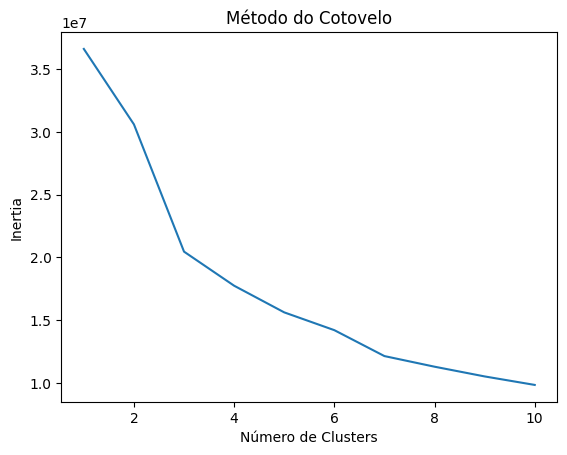

In [30]:
plt.figure()
plt.plot(range(1, 11), inertia)
plt.xlabel("Número de Clusters")
plt.ylabel("Inertia")
plt.title("Método do Cotovelo")
plt.show()

In [34]:
# Tentnado com 4 clusters

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

X["cluster"] = clusters

In [ ]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)